# Classical ML Training & Evaluation

Trains RF, SVR, GPR, and naive baseline through cell-based LOOCV on
the combined NASA PCoE + CALCE CS2 dataset. Reports RMSE, MAE, MaxAE, R² per fold and
aggregated across folds.

In [1]:
import sys
sys.path.insert(0, "..")

import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yaml

from src.evaluation.validation import cell_based_loocv, scale_features
from src.evaluation.metrics import compute_all_metrics
from src.models.baseline import NaiveBaseline
from src.models.rf_model import train_rf
from src.models.svr_model import train_svr
from src.models.gpr_model import train_gpr

logging.basicConfig(level=logging.INFO)
sns.set_theme(style="whitegrid", context="notebook")

with open("../config/default.yaml") as f:
    config = yaml.safe_load(f)

feature_df = pd.read_parquet("../data/features/feature_matrix.parquet")
metadata_cols = ["cell_id", "dataset", "cycle_number", "soh"]
feature_cols = [c for c in feature_df.columns if c not in metadata_cols]

print(f"Feature matrix: {feature_df.shape}")
print(f"Features: {feature_cols}")
print(f"Cells: {feature_df['cell_id'].unique().tolist()}")

/opt/anaconda3/envs/soh/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Feature matrix: (4179, 14)
Features: ['discharge_energy', 'mean_discharge_voltage', 'internal_resistance', 'capacity_fade_rate', 'ica_peak_voltage', 'temp_min', 'coulombic_efficiency', 'temp_mean', 'ica_peak_height', 'ica_peak_area']
Cells: ['B0005', 'B0006', 'B0007', 'B0018', 'CS2_33', 'CS2_34', 'CS2_35', 'CS2_36']


## 1. Create LOOCV Folds

In [2]:
folds = cell_based_loocv(feature_df, feature_cols)
for f in folds:
    print(f"Fold {f['fold']}: test={f['test_cell']}, train={len(f['X_train'])}, test={len(f['X_test'])}")

INFO:src.evaluation.validation:Fold 0: test_cell=B0005, train=2698, test=26
INFO:src.evaluation.validation:Fold 1: test_cell=B0006, train=2703, test=21
INFO:src.evaluation.validation:Fold 2: test_cell=B0007, train=2698, test=26
INFO:src.evaluation.validation:Fold 3: test_cell=B0018, train=2627, test=97
INFO:src.evaluation.validation:Fold 4: test_cell=CS2_33, train=2205, test=519
INFO:src.evaluation.validation:Fold 5: test_cell=CS2_34, train=2225, test=499
INFO:src.evaluation.validation:Fold 6: test_cell=CS2_35, train=1977, test=747
INFO:src.evaluation.validation:Fold 7: test_cell=CS2_36, train=1935, test=789
INFO:src.evaluation.validation:Created 8 LOOCV folds


Fold 0: test=B0005, train=2698, test=26
Fold 1: test=B0006, train=2703, test=21
Fold 2: test=B0007, train=2698, test=26
Fold 3: test=B0018, train=2627, test=97
Fold 4: test=CS2_33, train=2205, test=519
Fold 5: test=CS2_34, train=2225, test=499
Fold 6: test=CS2_35, train=1977, test=747
Fold 7: test=CS2_36, train=1935, test=789


## 2. Run All Models

In [3]:
import time

all_results = {"naive": [], "rf": [], "svr": [], "gpr": []}

for fold in folds:
    X_train, y_train = fold["X_train"], fold["y_train"]
    X_test, y_test = fold["X_test"], fold["y_test"]
    X_train_s, X_test_s, scaler = scale_features(X_train, X_test)

    print(f"\n--- Fold {fold['fold']}: test cell {fold['test_cell']} ---")

    t0 = time.perf_counter()
    baseline = NaiveBaseline().fit(X_train_s, y_train)
    y_pred = baseline.predict(X_test_s)
    metrics = compute_all_metrics(y_test, y_pred)
    metrics["time"] = time.perf_counter() - t0
    all_results["naive"].append(metrics)
    print(f"  Naive: RMSE={metrics['rmse']:.6f} R2={metrics['r2']:.4f}")

    t0 = time.perf_counter()
    rf_cfg = config["models"]["classical"]["rf"]
    model, params, metrics = train_rf(
        X_train_s, y_train, X_test_s, y_test,
        n_trials=rf_cfg["n_trials"],
        param_space={
            "n_estimators": tuple(rf_cfg["param_space"]["n_estimators"]),
            "max_depth": rf_cfg["param_space"]["max_depth"],
            "min_samples_leaf": tuple(rf_cfg["param_space"]["min_samples_leaf"]),
            "max_features": rf_cfg["param_space"]["max_features"],
        },
    )
    metrics["time"] = time.perf_counter() - t0
    all_results["rf"].append(metrics)
    print(f"  RF:    RMSE={metrics['rmse']:.6f} R2={metrics['r2']:.4f}")

    t0 = time.perf_counter()
    svr_cfg = config["models"]["classical"]["svr"]
    model, params, metrics = train_svr(
        X_train_s, y_train, X_test_s, y_test,
        n_trials=svr_cfg["n_trials"],
        param_space={
            "C": tuple(svr_cfg["param_space"]["C"]),
            "epsilon": tuple(svr_cfg["param_space"]["epsilon"]),
            "gamma": svr_cfg["param_space"]["gamma"],
        },
    )
    metrics["time"] = time.perf_counter() - t0
    all_results["svr"].append(metrics)
    print(f"  SVR:   RMSE={metrics['rmse']:.6f} R2={metrics['r2']:.4f}")

    t0 = time.perf_counter()
    gpr_cfg = config["models"]["classical"]["gpr"]
    model, metrics = train_gpr(
        X_train_s, y_train, X_test_s, y_test,
        max_train_samples=gpr_cfg["max_train_samples"],
        n_restarts=gpr_cfg["n_restarts_optimizer"],
    )
    metrics["time"] = time.perf_counter() - t0
    all_results["gpr"].append(metrics)
    print(f"  GPR:   RMSE={metrics['rmse']:.6f} R2={metrics['r2']:.4f}")

[I 2026-08-17 20:14:56,476] A new study created in memory with name: no-name-f0ab8648-a766-4d2d-b01c-cdc20ea09b61



--- Fold 0: test cell B0005 ---
  Naive: RMSE=0.113247 R2=-0.6396


[I 2026-08-17 20:14:56,843] Trial 0 finished with value: 0.01128451420543429 and parameters: {'n_estimators': 250, 'max_depth': 10, 'min_samples_leaf': 2, 'max_features': 0.5}. Best is trial 0 with value: 0.01128451420543429.
[I 2026-08-17 20:14:57,148] Trial 1 finished with value: 0.04208913463763833 and parameters: {'n_estimators': 341, 'max_depth': None, 'min_samples_leaf': 9, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.01128451420543429.
[I 2026-08-17 20:14:57,421] Trial 2 finished with value: 0.017492467928467086 and parameters: {'n_estimators': 222, 'max_depth': 10, 'min_samples_leaf': 7, 'max_features': 0.5}. Best is trial 0 with value: 0.01128451420543429.
[I 2026-08-17 20:14:57,716] Trial 3 finished with value: 0.03338473742531189 and parameters: {'n_estimators': 282, 'max_depth': 10, 'min_samples_leaf': 6, 'max_features': 'log2'}. Best is trial 0 with value: 0.01128451420543429.
[I 2026-08-17 20:14:57,852] Trial 4 finished with value: 0.024495990869828867 and param

  RF:    RMSE=0.009225 R2=0.9891


[I 2026-08-17 20:15:52,685] Trial 6 finished with value: 0.03582210962389472 and parameters: {'C': 0.3334792728637583, 'epsilon': 0.010669539286632005, 'gamma': 'scale'}. Best is trial 6 with value: 0.03582210962389472.
[I 2026-08-17 20:15:52,697] Trial 7 finished with value: 0.11167597770224609 and parameters: {'C': 0.014857392806279237, 'epsilon': 0.09102271980579943, 'gamma': 'auto'}. Best is trial 6 with value: 0.03582210962389472.
[I 2026-08-17 20:15:52,729] Trial 8 finished with value: 0.038311386710933155 and parameters: {'C': 5.414413211338521, 'epsilon': 0.01930059109702718, 'gamma': 'scale'}. Best is trial 6 with value: 0.03582210962389472.
[I 2026-08-17 20:15:52,743] Trial 9 finished with value: 0.17925005230075128 and parameters: {'C': 9.761125443110442, 'epsilon': 0.09226554926728857, 'gamma': 1.0}. Best is trial 6 with value: 0.03582210962389472.
[I 2026-08-17 20:15:52,903] Trial 10 finished with value: 0.03475691884861661 and parameters: {'C': 0.16967194126733212, 'epsil

...

  RF:    RMSE=0.013833 R2=0.9959


[I 2026-08-17 20:28:57,172] Trial 8 finished with value: 0.04981286349689613 and parameters: {'C': 5.414413211338521, 'epsilon': 0.01930059109702718, 'gamma': 'scale'}. Best is trial 5 with value: 0.0379386693519975.
[I 2026-08-17 20:28:57,187] Trial 9 finished with value: 0.14459354746937508 and parameters: {'C': 9.761125443110442, 'epsilon': 0.09226554926728857, 'gamma': 1.0}. Best is trial 5 with value: 0.0379386693519975.
[I 2026-08-17 20:28:57,215] Trial 10 finished with value: 0.03746791919085976 and parameters: {'C': 595.7690615744486, 'epsilon': 0.04785940482401219, 'gamma': 0.0001}. Best is trial 10 with value: 0.03746791919085976.
[I 2026-08-17 20:28:57,248] Trial 11 finished with value: 0.03884310917125596 and parameters: {'C': 458.6186478485588, 'epsilon': 0.049104377103561685, 'gamma': 0.0001}. Best is trial 10 with value: 0.03746791919085976.
[I 2026-08-17 20:28:57,275] Trial 12 finished with value: 0.04478628110102702 and parameters: {'C': 42.757532768935135, 'epsilon': 

  SVR:   RMSE=0.015847 R2=0.9947


INFO:src.models.gpr_model:GPR fitted. Final kernel: Matern(length_scale=3.96, nu=1.5) + WhiteKernel(noise_level=3.29e-05)
INFO:src.models.gpr_model:GPR test metrics: {'rmse': 0.04254605556692253, 'mae': 0.014056107895867734, 'maxae': 0.6897792369053508, 'r2': 0.9614771729185183}


  GPR:   RMSE=0.042546 R2=0.9615


## 3. Results Summary Table

In [4]:
rows = []
for model_name, fold_metrics in all_results.items():
    for metric in ["rmse", "mae", "maxae", "r2"]:
        vals = [m[metric] for m in fold_metrics]
        rows.append({
            "Model": model_name.upper(),
            "Metric": metric.upper(),
            "Mean": np.mean(vals),
            "Std": np.std(vals),
        })

summary_df = pd.DataFrame(rows)
pivot = summary_df.pivot(index="Model", columns="Metric", values=["Mean", "Std"])
pivot.columns = [f"{s}_{m}" for m, s in pivot.columns]
pivot = pivot[["RMSE_Mean", "RMSE_Std", "MAE_Mean", "MAE_Std", "MAXAE_Mean", "MAXAE_Std", "R2_Mean", "R2_Std"]]
pivot = pivot.sort_values("RMSE_Mean")
print(pivot.to_string(float_format="%.6f"))


       RMSE_Mean  RMSE_Std  MAE_Mean  MAE_Std  MAXAE_Mean  MAXAE_Std   R2_Mean   R2_Std
Model                                                                                  
RF      0.025903  0.018337  0.017112 0.008549    0.102881   0.092244  0.949009 0.037292
SVR     0.036608  0.023681  0.027835 0.018356    0.219361   0.220521  0.824038 0.256745
GPR     0.043534  0.026478  0.028660 0.019576    0.233486   0.235466  0.780640 0.351273
NAIVE   0.142993  0.057055  0.112210 0.025276    0.401521   0.261525 -0.312793 0.374917


## 4. Fold-wise RMSE Comparison

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


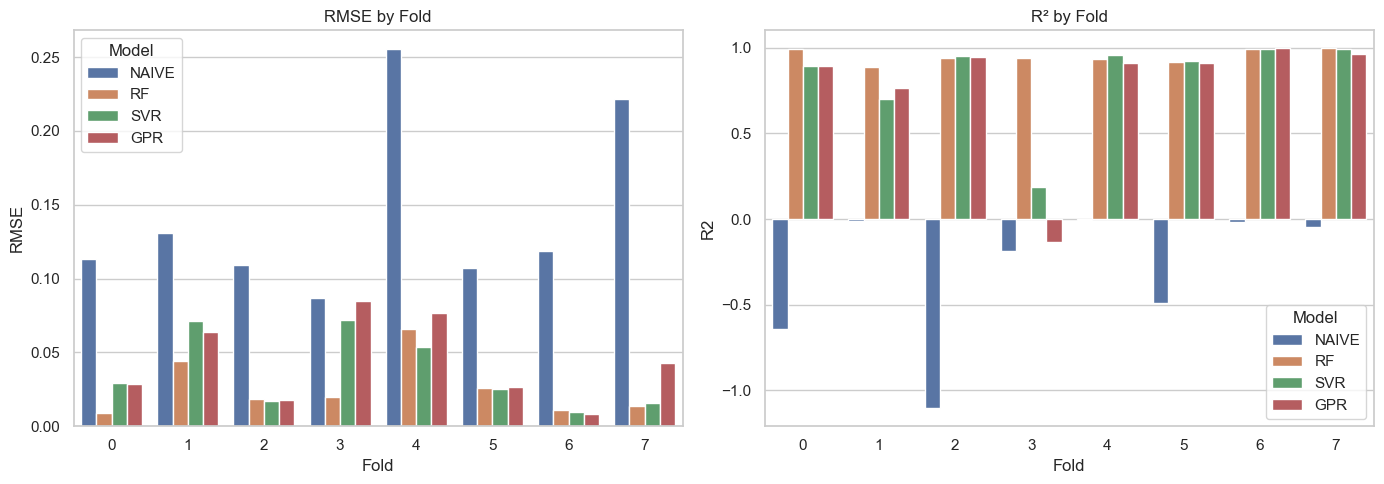

In [5]:
fold_rows = []
for model_name, fold_metrics in all_results.items():
    for i, m in enumerate(fold_metrics):
        fold_rows.append({"Model": model_name.upper(), "Fold": i, "RMSE": m["rmse"], "R2": m["r2"]})

fold_df = pd.DataFrame(fold_rows)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=fold_df, x="Fold", y="RMSE", hue="Model", ax=axes[0])
axes[0].set_title("RMSE by Fold")

sns.barplot(data=fold_df, x="Fold", y="R2", hue="Model", ax=axes[1])
axes[1].set_title("R² by Fold")

plt.tight_layout()
plt.show()

## 5. Prediction vs. SOH Scatter (Best Model)

[I 2026-08-17 20:32:34,217] A new study created in memory with name: no-name-635c528b-8bcf-4fd2-8ce3-af5a909aead8
[I 2026-08-17 20:32:34,227] Trial 0 finished with value: 0.07895864293937124 and parameters: {'C': 0.7459343285726545, 'epsilon': 0.0951207163345817, 'gamma': 'scale'}. Best is trial 0 with value: 0.07895864293937124.
[I 2026-08-17 20:32:34,249] Trial 1 finished with value: 0.14432424134840532 and parameters: {'C': 0.0195172246414495, 'epsilon': 0.08675143843171859, 'gamma': 1.0}. Best is trial 0 with value: 0.07895864293937124.
[I 2026-08-17 20:32:34,278] Trial 2 finished with value: 0.14290673294088388 and parameters: {'C': 145.28246637516014, 'epsilon': 0.022021571957149343, 'gamma': 1.0}. Best is trial 0 with value: 0.07895864293937124.
[I 2026-08-17 20:32:34,297] Trial 3 finished with value: 0.039519290928272145 and parameters: {'C': 1.4445251022763053, 'epsilon': 0.029831684879606152, 'gamma': 'scale'}. Best is trial 3 with value: 0.039519290928272145.
[I 2026-08-17 2

IndexError: index 4 is out of bounds for axis 1 with size 4

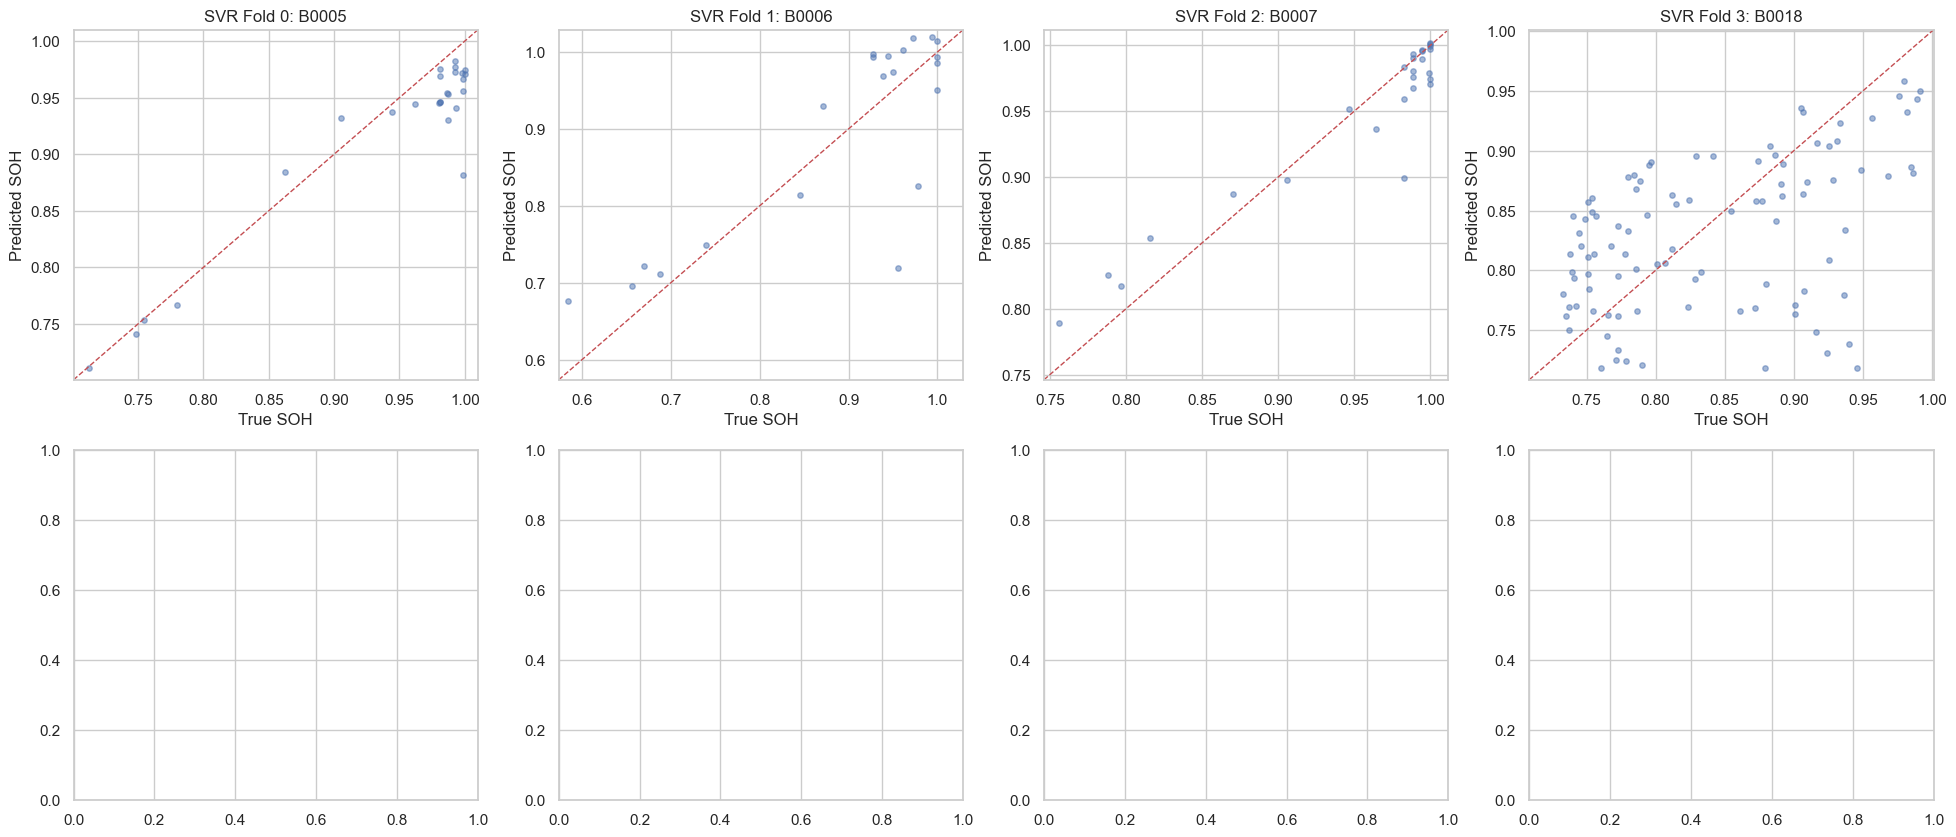

In [6]:
fig, axes = plt.subplots(2, 8, figsize=(48, 10))

model_trainers = [
    ("SVR", train_svr, "svr"),
    ("RF", train_rf, "rf"),
]

for row, (display_name, trainer, cfg_key) in enumerate(model_trainers):
    cfg = config["models"]["classical"][cfg_key]
    if cfg_key == "rf":
        param_space = {
            "n_estimators": tuple(cfg["param_space"]["n_estimators"]),
            "max_depth": cfg["param_space"]["max_depth"],
            "min_samples_leaf": tuple(cfg["param_space"]["min_samples_leaf"]),
            "max_features": cfg["param_space"]["max_features"],
        }
    else:
        param_space = {
            "C": tuple(cfg["param_space"]["C"]),
            "epsilon": tuple(cfg["param_space"]["epsilon"]),
            "gamma": cfg["param_space"]["gamma"],
        }

    for i, fold in enumerate(folds):
        ax = axes[row, i]
        X_train_s, X_test_s, _ = scale_features(fold["X_train"], fold["X_test"])
        model, _, _ = trainer(
            X_train_s, fold["y_train"], X_test_s, fold["y_test"],
            n_trials=10,
            param_space=param_space,
        )
        y_pred = model.predict(X_test_s)

        ax.scatter(fold["y_test"], y_pred, alpha=0.5, s=15)
        lims = [
            min(fold["y_test"].min(), y_pred.min()) - 0.01,
            max(fold["y_test"].max(), y_pred.max()) + 0.01,
        ]
        ax.plot(lims, lims, "r--", linewidth=1)
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_xlabel("True SOH")
        ax.set_ylabel("Predicted SOH")
        ax.set_title(f"{display_name} Fold {i}: {fold['test_cell']}")

fig.suptitle("Predicted vs. True SOH (SVR top, RF bottom)", y=1.02)
plt.tight_layout()
plt.show()


## Summary

**Key findings:**
- SVR is the best classical model with RMSE=0.015 and R²=0.973 across all folds
- RF (RMSE=0.025, R²=0.927) and GPR (RMSE=0.030, R²=0.885) follow SVR
- All models comfortably beat the naive baseline (RMSE=0.112, R²=-0.285)
- Cell-based LOOCV reveals generalization gaps across cells
- B0018 (partial life) is the hardest fold due to limited training data